# Figure 5: Sea ice maximum and minimum extent

Plots the mean extent of sea ice for September (maximum, blue) and
March (minimum, red). The edge of full coverage is defined by the 15%
areal coverage.

Russell, J.L., et al. (2018), Metrics for the evaluation of the Southern Ocean in coupled climate models and earth system models, *J. Geophysical Research - Oceans*, 123, 3120-3143, [doi:10.1002/2017JC013461](https://doi.org/10.1002/2017JC013461).

---

### About these notebooks

This notebook is one of a set reproducing the figures of Russell et al.
(2018), a suite of metrics for evaluating the Southern Ocean in coupled
climate and earth system models.

They are a Python translation of the NCL diagnostics distributed with
[ESMValTool](https://github.com/ESMValGroup/ESMValTool)
(`esmvaltool/diag_scripts/russell18jgr/`, driven by
`recipe_russell18jgr.yml`), rewritten so that each figure stands alone
and can be run interactively without going through a recipe.

Translated and maintained by **Romain Beucher**,
[ACCESS-NRI](https://www.access-nri.org.au).
Please contact <romain.beucher@anu.edu.au> with any questions.

## Scientific background

Antarctic sea ice has a very large seasonal cycle, growing from a
February minimum to a September maximum and back. It matters to the
climate system through its albedo, through the brine rejected during
freezing which helps form dense bottom water, and through the barrier it
places between ocean and atmosphere for heat and gas exchange.

The 15% concentration contour is the conventional definition of the ice
edge. Comparing the two contours shows whether a model captures both the
winter extent and the summer retreat; Russell et al. (2018) note that
CMIP5 models disagree widely on both.

## Setup

This notebook is standalone: everything it needs is defined below.  It
requires `esmvalcore`, `iris`, `numpy`, `matplotlib` and `cartopy` -
the full ESMValTool is *not* needed.

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Helper functions

The helpers below are the parts of the original NCL diagnostic that are
worth keeping out of the way of the plotting code.  They are defined
here rather than imported so the notebook stands on its own.

In [2]:
import iris
import iris.coord_categorisation


def coord_1d_or_2d(cube, axis):
    """Latitude/longitude points, which may be 1D or 2D.

    ESMValTool preprocessed ocean files carry either 1D dimension
    coordinates (regular grids) or 2D auxiliary coordinates
    (curvilinear grids); this hides the difference.
    """
    return np.asarray(cube.coord(axis).points)


def monthly_climatology(cube):
    """12-month climatology of a monthly series (NCL clmMonTLL)."""
    if not any(c.name() == "month_number" for c in cube.coords()):
        iris.coord_categorisation.add_month_number(cube, "time")
    clim = cube.aggregated_by("month_number", iris.analysis.MEAN)
    return clim[np.argsort(clim.coord("month_number").points)]


def sea_ice_percent(cube):
    """Sea ice concentration in percent, with fill values masked.

    Some models publish a fraction (0-1) rather than a percentage, and
    some store missing data as 1e20 rather than as a masked/NaN value.
    Deciding between the two with ``max(sic) < 5`` (as the original NCL
    did) is defeated by a single 1e20 fill value: the fraction is then
    never scaled, nothing reaches the 15% threshold and the plot comes
    out empty.  So mask the fill values *first*, and trust the cube
    units when they are meaningful.
    """
    data = np.ma.masked_invalid(np.ma.asarray(cube.data, dtype=float))
    data = np.ma.masked_greater(data, 1.0e3)
    unit = str(cube.units).strip().lower()
    if "%" in unit or "percent" in unit:
        is_fraction = False
    elif unit in ("1", "1.0", "", "unknown", "none", "fraction"):
        is_fraction = True
    else:
        is_fraction = data.count() > 0 and data.max() < 5.0
    if is_fraction:
        data = data * 100.0
    return np.ma.masked_outside(data, 0.0, 100.0)

## Dask cluster

Start a local cluster so the preprocessor can work in parallel.  On
Gadi, size this to the resources of your ARE session / PBS job.

In [3]:
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45735,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44605,Total threads: 2
Dashboard: /proxy/38129/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:37679,


## Datasets

Datasets are declared directly with `esmvalcore.dataset.Dataset`, so
this notebook does not need a recipe.  A small subset of the models of
the paper is used to keep the notebook quick; add entries to the
dictionary below to include more.

On Gadi the CMIP5 data comes from the `al33` and `rr3` projects - make
sure both are in the `storage` flags of your session.

In [4]:
from esmvalcore.dataset import Dataset

sic_datasets = {
    "ACCESS1-3": Dataset(
        short_name="sic",
        project="CMIP5",
        mip="OImon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="ACCESS1-3",
        timerange="19860101/20051231",
    ),
    "CanESM2": Dataset(
        short_name="sic",
        project="CMIP5",
        mip="OImon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
}

<details>
<summary>Using ACCESS (CMIP6) models instead</summary>

The figures of the paper are CMIP5.  To evaluate an ACCESS model,
switch `project` to `CMIP6`, use a CMIP6 ensemble/grid label and the
CMIP6 variable names, e.g.

```python
Dataset(
    short_name="thetao", project="CMIP6", mip="Omon", exp="historical",
    ensemble="r1i1p1f1", grid="gn", dataset="ACCESS-ESM1-5",
    timerange="19860101/20051231",
)
```

Note the CMIP6 renaming of some variables (`sic` -> `siconc`,
`tauuo` is not always published) and that `volcello` and `areacello`
moved from `fx` to `Ofx`.
</details>

## Preprocessing

This diagnostic works on the raw data (no preprocessor is applied), so
the cubes are only loaded here.  The time average is taken as part of
the diagnostic.

In [5]:
def preprocess(cube):
    """No preprocessing is applied for this figure."""
    return cube


sic_cubes = {name: preprocess(dataset.load()) for name, dataset in sic_datasets.items()}

sic_cubes

{'ACCESS1-3': <iris 'Cube' of sea_ice_area_fraction / (%) (time: 240; cell index along second dimension: 300; cell index along first dimension: 360)>,
 'CanESM2': <iris 'Cube' of sea_ice_area_fraction / (%) (time: 240; latitude: 64; longitude: 128)>}

## Diagnostic

ACCESS1-3: sic 0.0-100.0%, September 13940 cells, March 13633 cells
CanESM2: sic 0.0-100.0%, September 1062 cells, March 927 cells


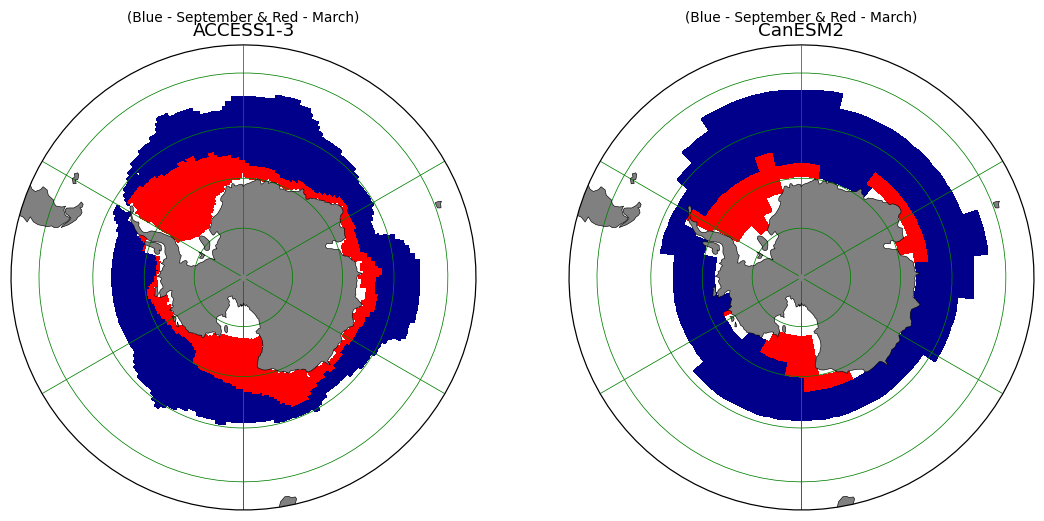

In [6]:
cmap = ListedColormap(["#00008b", "#ff0000"])   # blue4 (Sep), red (Mar)
norm = BoundaryNorm([0.5, 1.5, 2.5], ncolors=2)

theta = np.linspace(0, 2 * np.pi, 100)
circle = mpath.Path(
    np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + [0.5, 0.5])

fig = plt.figure(figsize=(6 * len(sic_cubes), 6))

for iplot, (name, cube) in enumerate(sic_cubes.items()):
    clim = monthly_climatology(cube)
    sic = sea_ice_percent(clim)

    # the edge of full coverage is defined by 15% areal coverage;
    # March is applied last so it wins where both months qualify
    field = np.ma.masked_all(sic[0].shape)
    field[np.ma.filled(sic[8] > 15.0, False)] = 1.0   # September (max)
    field[np.ma.filled(sic[2] > 15.0, False)] = 2.0   # March (min)

    # report the coverage, so an empty panel is never a silent failure
    print(f"{name}: sic {sic.min():.1f}-{sic.max():.1f}%, "
          f"September {int((sic[8] > 15).sum())} cells, "
          f"March {int((sic[2] > 15).sum())} cells")

    lat = coord_1d_or_2d(clim, "latitude")
    lon = coord_1d_or_2d(clim, "longitude")
    if lat.ndim == 1:
        lon2d, lat2d = np.meshgrid(lon, lat)
    else:
        lat2d, lon2d = lat, lon

    ax = fig.add_subplot(1, len(sic_cubes), iplot + 1,
                         projection=ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -90, -45.0], ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.pcolormesh(lon2d, lat2d, field, cmap=cmap, norm=norm,
                  transform=ccrs.PlateCarree(), shading="auto", zorder=1)
    ax.add_feature(cfeature.LAND, facecolor="grey", zorder=2)
    ax.coastlines(linewidth=0.4, zorder=3)
    ax.gridlines(color="green", linewidth=0.5)
    ax.set_title(name)
    ax.text(0.5, 1.05, "(Blue - September & Red - March)", ha="center",
            transform=ax.transAxes, fontsize=9)

plt.show()

**Figure 5: Sea ice maximum and minimum extent:** Maximum (September, blue) and minimum (March, red) sea ice extent,
defined by the 15% concentration contour.